In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import colors
import networkx as nx
from collections import Counter

rcParams['figure.figsize'] = (5, 5)
rcParams['font.size']=16

try:
  import infomap as im
except:
  !pip install Infomap
  import infomap as im



In [2]:
def represent_degree_distribution(G,scale='linear',rep='bars',weight=False):
    if(weight==False):
        degree_sequence=[G.degree(node) for node in G.nodes()]
    else:
        degree_sequence=[G.degree(node,weight='weight') for node in G.nodes()]
        
    degree_counts = Counter(degree_sequence)
    min_degree=min(degree_sequence)
    max_degree=max(degree_sequence)

    degrees=list(degree_counts.keys())
    degree_count=list(degree_counts.values())

    fig,ax=plt.subplots(1,1,figsize=(5,5))
    if rep=='bars':
        ax.bar(degrees,degree_count)
    if rep=='scatter':
        ax.scatter(degrees,degree_count)
    
    if scale=='log':
        ax.set_xscale('log')
        ax.set_yscale('log')

    if(weight==False):
        ax.set_xlabel('Degree',fontsize=15)
    else:
        ax.set_xlabel('Strength',fontsize=15)
    ax.set_ylabel('#nodes',fontsize=15)
    ax.tick_params(which='major',axis='both',labelsize=15)    


In [3]:
def fit_CCDF(G,weight=False):
    if(weight==False):
        degree_sequence=[G.degree(node) for node in G.nodes()]
    else:
        degree_sequence=[G.degree(node,weight='weight') for node in G.nodes()]

    degree_counts = Counter(degree_sequence)
    min_degree=min(degree_sequence)
    max_degree=max(degree_sequence)

    degrees = list(range(min_degree, max_degree + 1))
    degree_count = [degree_counts.get(k, 0) for k in degrees]

    degrees=[degrees[i] for i in range(len(degrees)) if degree_count[i]!=0]
    degree_count=[degree_count[i] for i in range(len(degree_count)) if degree_count[i]!=0]

    
    cdf=np.cumsum(degree_count)/G.number_of_nodes() ### Get the cumulative sum of the distribution (without normalized)
    ccdf=np.ones(len(cdf))-cdf #### Get the CCDF 

    log_degree_fit=[np.log(degrees[i]) for i in range(len(degrees))][:-1] ## Last point should be excluded as 0 in logarithmic scale is not finite
    log_ccdf_fit=np.log(ccdf)[:-1]

    m,b = np.polyfit(log_degree_fit, log_ccdf_fit, 1) 

    theoretical=[np.exp(b)*k**m for k in degrees]

    fig,ax=plt.subplots(1,1,figsize=(5,5))

    ax.plot(degrees, theoretical,color='black',label=r'$\gamma-1=%.2f$'%(-m))
    ax.scatter(degrees, ccdf,label='data')


    ax.set_yscale('log')
    ax.set_xscale('log')


    if(weight==False):
        ax.set_xlabel('$k$',fontsize=15)
        ax.set_ylabel('$CCDF(k)$',fontsize=15)
    else:
        ax.set_xlabel('$s$',fontsize=15)
        ax.set_ylabel('$CCDF(s)$',fontsize=15)
    

    ax.tick_params(which='major',axis='both',labelsize=15)

    ax.legend()

# <span style='color:#2196f3'>Network analysis: Game of Thrones</span>



<span style='font-size:large'>With this notebook, we're going to put into practice the theory we've learned about complex networks to analyze the temporal evolution of the networks of Game of Thrones characters throughout the books, as well as the role each character plays in them. The network is built from 5 Game of Thrones books, with the nodes of the network being the different characters, and the connections between them are proportional to the number of times both characters' names appear together within an interval of less than 15 words.</span>


In [4]:
data=pd.read_csv('../Data/books.csv',names=['Source','Target','Type','weight','Book'],skiprows=1) ##

In [5]:
data

,Source,Target,Type,weight,Book
0,Addam-Marbrand,Jaime-Lannister,Undirected,3,1.0
1,Addam-Marbrand,Tywin-Lannister,Undirected,6,1.0
2,Aegon-I-Targaryen,Daenerys-Targaryen,Undirected,5,1.0
3,Aegon-I-Targaryen,Eddard-Stark,Undirected,4,1.0
4,Aemon-Targaryen-(Maester-Aemon),Alliser-Thorne,Undirected,4,1.0
...,...,...,...,...,...
3904,Tyrion-Lannister,Ysilla,undirected,11,5.0
3905,Tywin-Lannister,Wylis-Manderly,undirected,3,5.0
3906,Victarion-Greyjoy,Wulfe,undirected,3,5.0
3907,Walder-Frey-(son-of-Jammos),Walder-Frey-(son-of-Merrett),undirected,10,5.0


Let's construct the network

In [6]:
first_book_df=data[data['Book']==1.0]


In [7]:
first_book_df

,Source,Target,Type,weight,Book
0,Addam-Marbrand,Jaime-Lannister,Undirected,3,1.0
1,Addam-Marbrand,Tywin-Lannister,Undirected,6,1.0
2,Aegon-I-Targaryen,Daenerys-Targaryen,Undirected,5,1.0
3,Aegon-I-Targaryen,Eddard-Stark,Undirected,4,1.0
4,Aemon-Targaryen-(Maester-Aemon),Alliser-Thorne,Undirected,4,1.0
...,...,...,...,...,...
679,Tyrion-Lannister,Willis-Wode,Undirected,4,1.0
680,Tyrion-Lannister,Yoren,Undirected,10,1.0
681,Tywin-Lannister,Varys,Undirected,4,1.0
682,Tywin-Lannister,Walder-Frey,Undirected,8,1.0


In [8]:
## Create a graph object
G=nx.from_pandas_edgelist(first_book_df,'Source','Target',edge_attr='weight')

In [9]:
print('The number of nodes is:',G.number_of_nodes())  
print('The number of edges is:',G.number_of_edges())  

The number of nodes is: 187
The number of edges is: 684


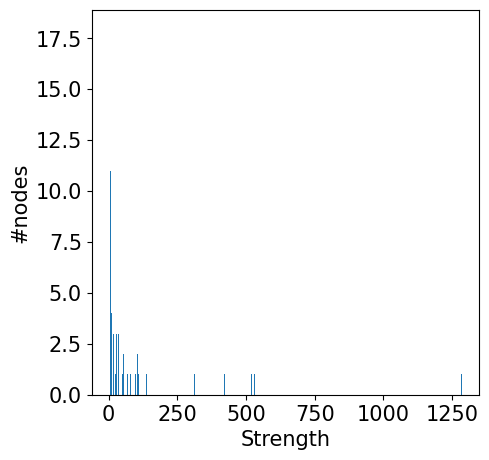

In [14]:
# Represent the degree distribution
represent_degree_distribution(G,scale='linear',rep='bars', weight=True)


/var/folders/y_/1f6tyxqn3hd98mt_8yc4vp0r0000gn/T/ipykernel_50688/2778416597.py:22: RuntimeWarning: divide by zero encountered in log
  log_ccdf_fit=np.log(ccdf)[:-1]


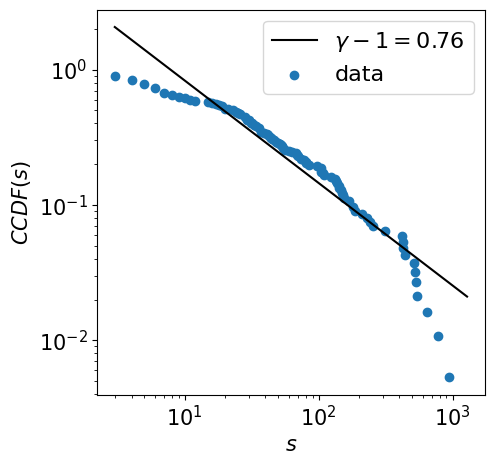

In [15]:
fit_CCDF(G, weight=True)

It seems clear that the number of acquaintances does not follow a power-law behavior

#### Let us now take into account weights information

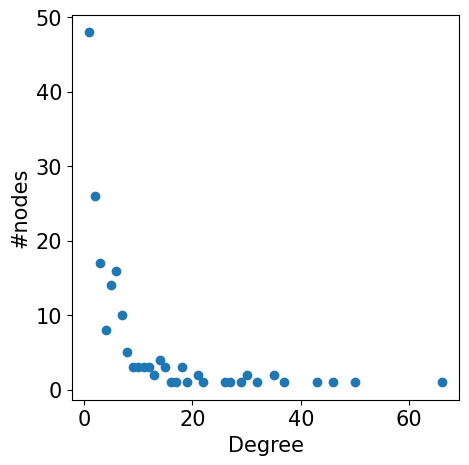

In [16]:
represent_degree_distribution(G,scale='linear',rep='scatter',weight=False) 

/var/folders/y_/1f6tyxqn3hd98mt_8yc4vp0r0000gn/T/ipykernel_50688/2778416597.py:22: RuntimeWarning: divide by zero encountered in log
  log_ccdf_fit=np.log(ccdf)[:-1]


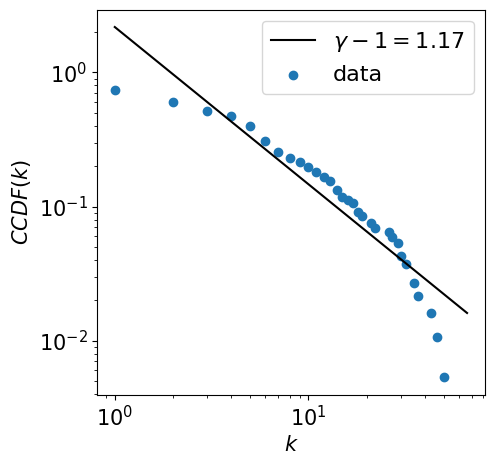

In [17]:
fit_CCDF(G,weight=False)

**Message** : Network is fat-tailed, presents scarcely connected nodes and hubs but the degree distribution does not follow any power-law behavior

### Network visualization

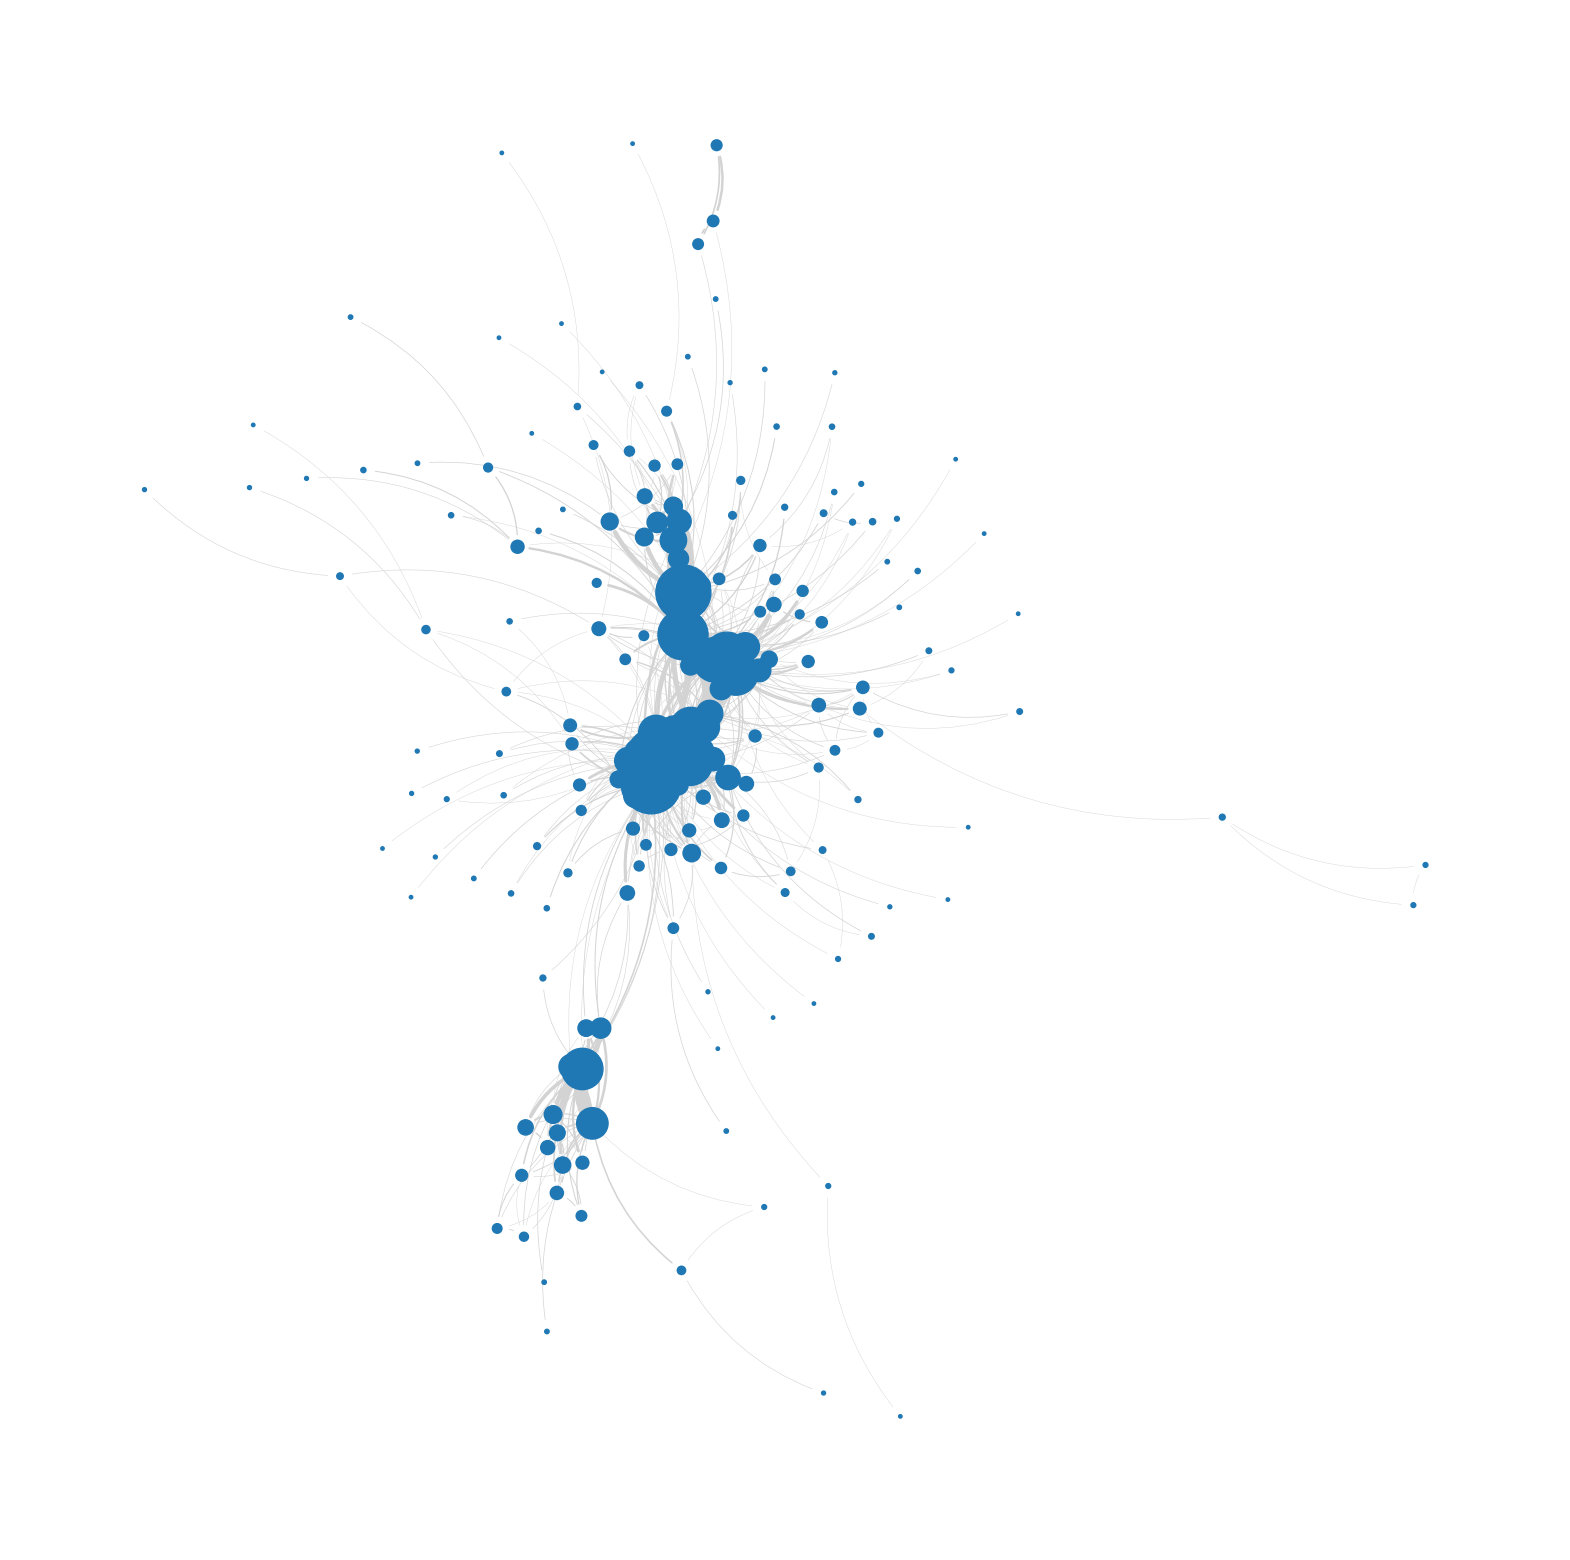

In [18]:
fig,ax=plt.subplots(1,1,figsize=(20,20))
### We fix the position of the nodes

positions=nx.spring_layout(G,k=.2,weight='weight')

## Size proportional to strength 
sizes=[2*G.degree(node,weight='weight') for node in G.nodes()]

## Set edge thickness proportional to the weight
thickness=[.1*G.edges()[edge]['weight'] for edge in G.edges()]

## We represent the network fixing the positions.
nx.draw_networkx_nodes(G,pos=positions,node_size=sizes)
nx.draw_networkx_edges(G,pos=positions,connectionstyle="arc3,rad=0.2",arrows=True,edge_color='lightgrey',width=thickness)
plt.box(False)

In [19]:
betweennes_centralities=nx.betweenness_centrality(G)

## Find the 5 nodes with highest betweenness centralities

highest_betweenness_nodes = sorted(betweennes_centralities, key=betweennes_centralities.get, reverse=True)[:10]

labels = {}    
for node in G.nodes():
    if node in highest_betweenness_nodes:
        #set the node name as the key and the label as its value 
        labels[node] = node

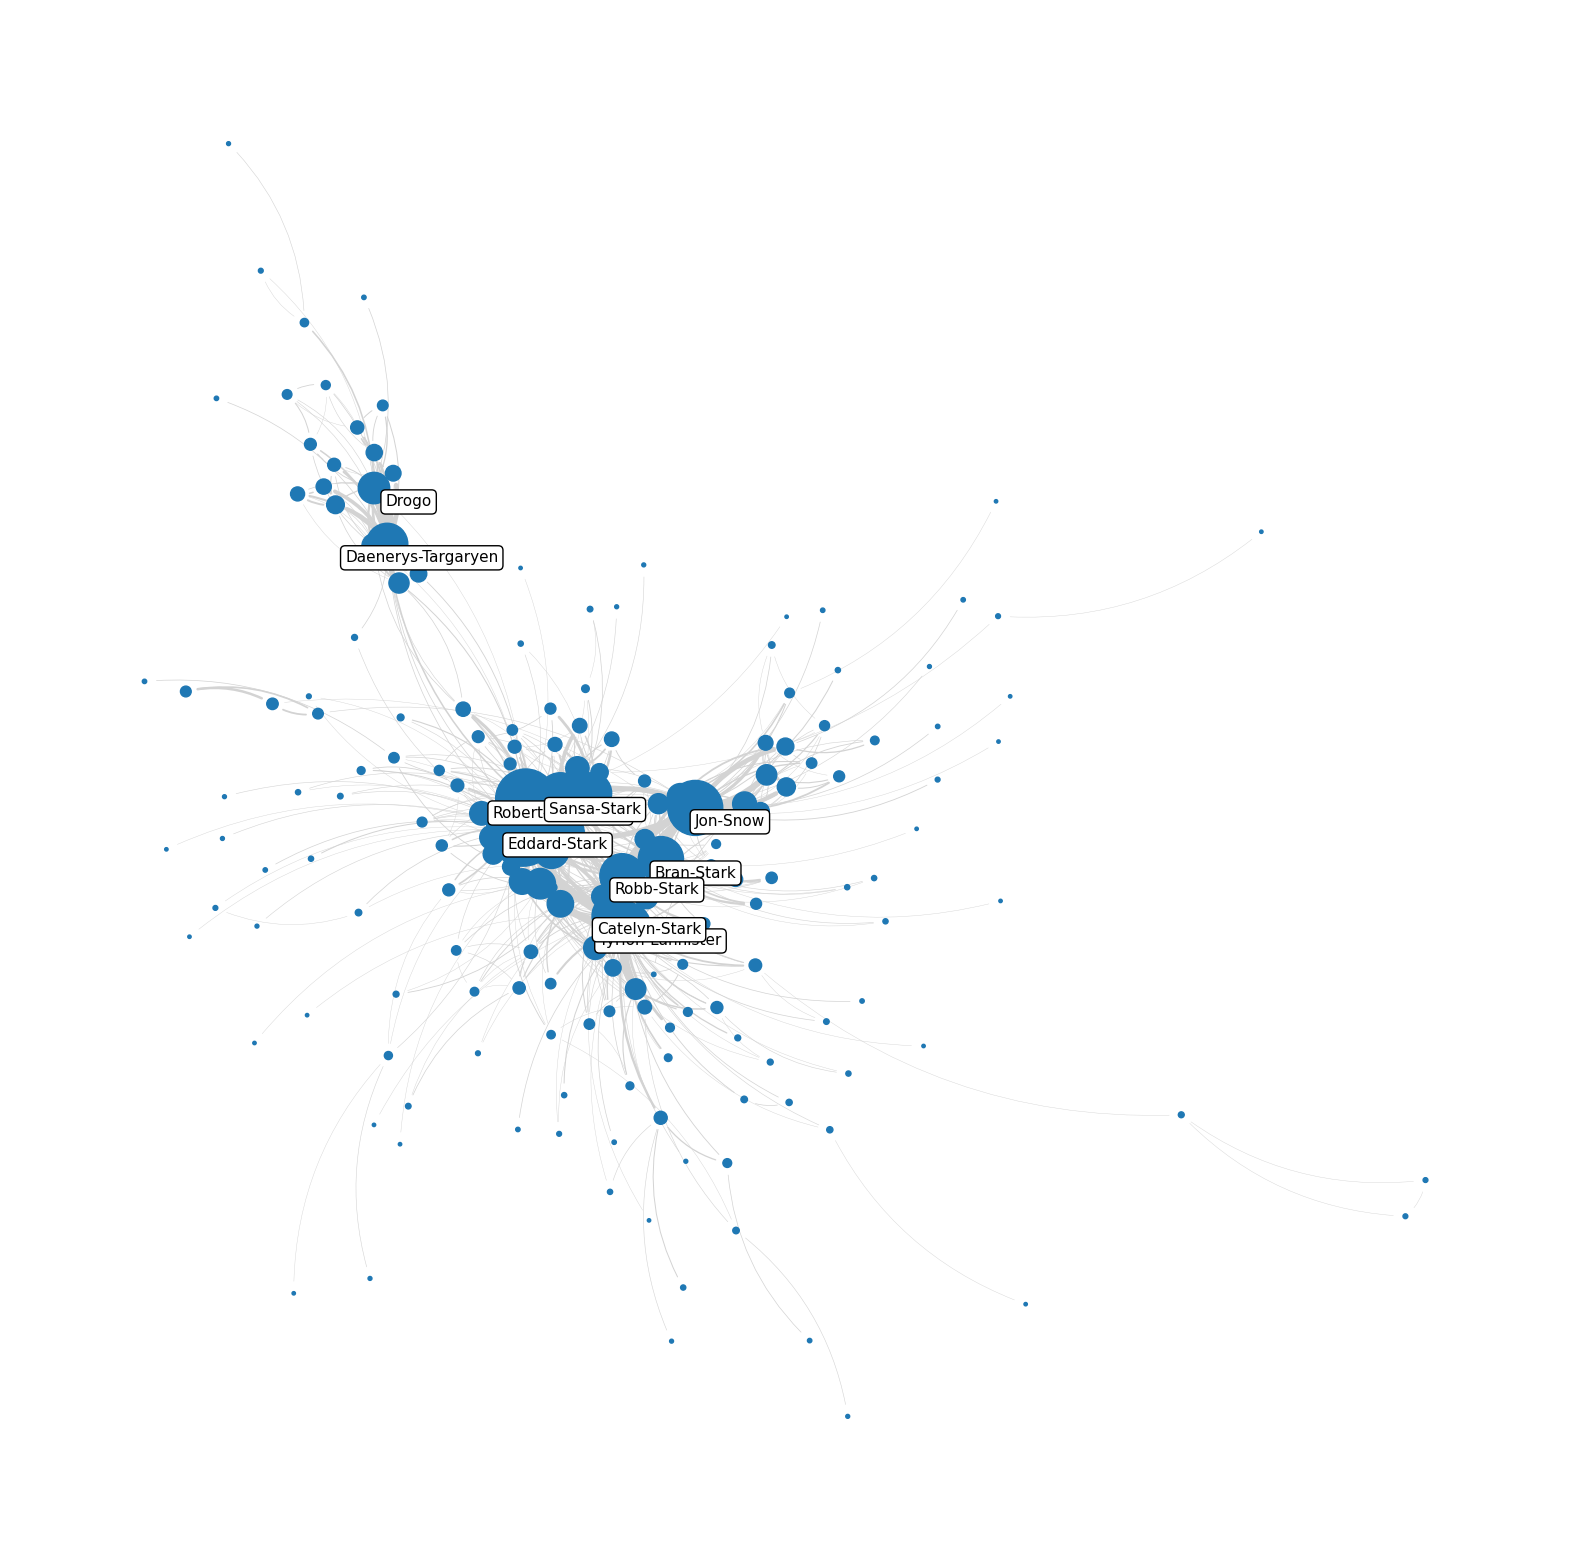

In [20]:
fig,ax=plt.subplots(1,1,figsize=(20,20))
### We fix the position of the nodes

positions=nx.spring_layout(G,k=.2,weight='weight',seed=1)

## Size proportional to strength 
sizes=[2*G.degree(node,weight='weight') for node in G.nodes()]


## Coordinates of the nodes' labels
pos_attrs = {}
for node, coords in positions.items():
    if node in highest_betweenness_nodes:
        pos_attrs[node] = (coords[0]+0.04, coords[1] - 0.02)

thickness=[.1*G.edges()[edge]['weight'] for edge in G.edges()]

## We represent the network fixing the positions.
nx.draw_networkx_nodes(G,pos=positions,node_size=sizes)
nx.draw_networkx_labels(G,pos=pos_attrs,labels=labels,bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=.3'),font_size=11)
nx.draw_networkx_edges(G,pos=positions,connectionstyle="arc3,rad=0.2",arrows=True,edge_color='lightgrey',width=thickness)
plt.box(False)

#### Community detection

Now, we focus on getting modules of nodes by using community detection algorithms. We will use three different algorithms, initially neglecting weights . Two of them (greedy, louvain) try to find the partition maximizing modularity whereas another one (Infomap) reduces the length of the information needed to describe the trajectory of random walkers across the network

In [22]:
communities_louvain=nx.community.louvain_communities(G) ## Louvain algorithm
communities_greedy=nx.community.greedy_modularity_communities(G) ## Greedy algorithm


In [23]:
## Community detection with Infomap
import infomap as im

im = im.Infomap(silent=True) 
mapping = im.add_networkx_graph(G)

im.run()

from collections import defaultdict

def infomap_to_networkx_communities(mapping,infomap_partition):
    community_dict = defaultdict(set)
    for node, community in infomap_partition.items():
        community_dict[community].add(mapping[node])
    
    return list(community_dict.values())
    
node_community_infomap = im.get_modules()
communities_infomap=infomap_to_networkx_communities(mapping, node_community_infomap)


In [24]:
def set_color_nodes(communities,G):
    colors=plt.cm.jet(np.linspace(0,1,len(communities))) ## Get the colors for the communities
    community_node={} ## Dictionary to store the community of each node
    count_community=0 ## Counter for the communities' labels

    for community in communities: ## For each community
        for node in community: ## For each node in the community
            community_node[node]=count_community ## Store the label of the community of the node
        count_community=count_community+1 ## Update the counter

    color_nodes=[] ## List to store the color of each node
    for node in G.nodes():  
        color_nodes.append(colors[community_node[node]]) ## Get the color of the node

    return color_nodes


In [25]:
colors_node_louvain=set_color_nodes(communities_louvain,G)
colors_node_greedy=set_color_nodes(communities_greedy,G)
colors_node_infomap=set_color_nodes(communities_infomap,G)

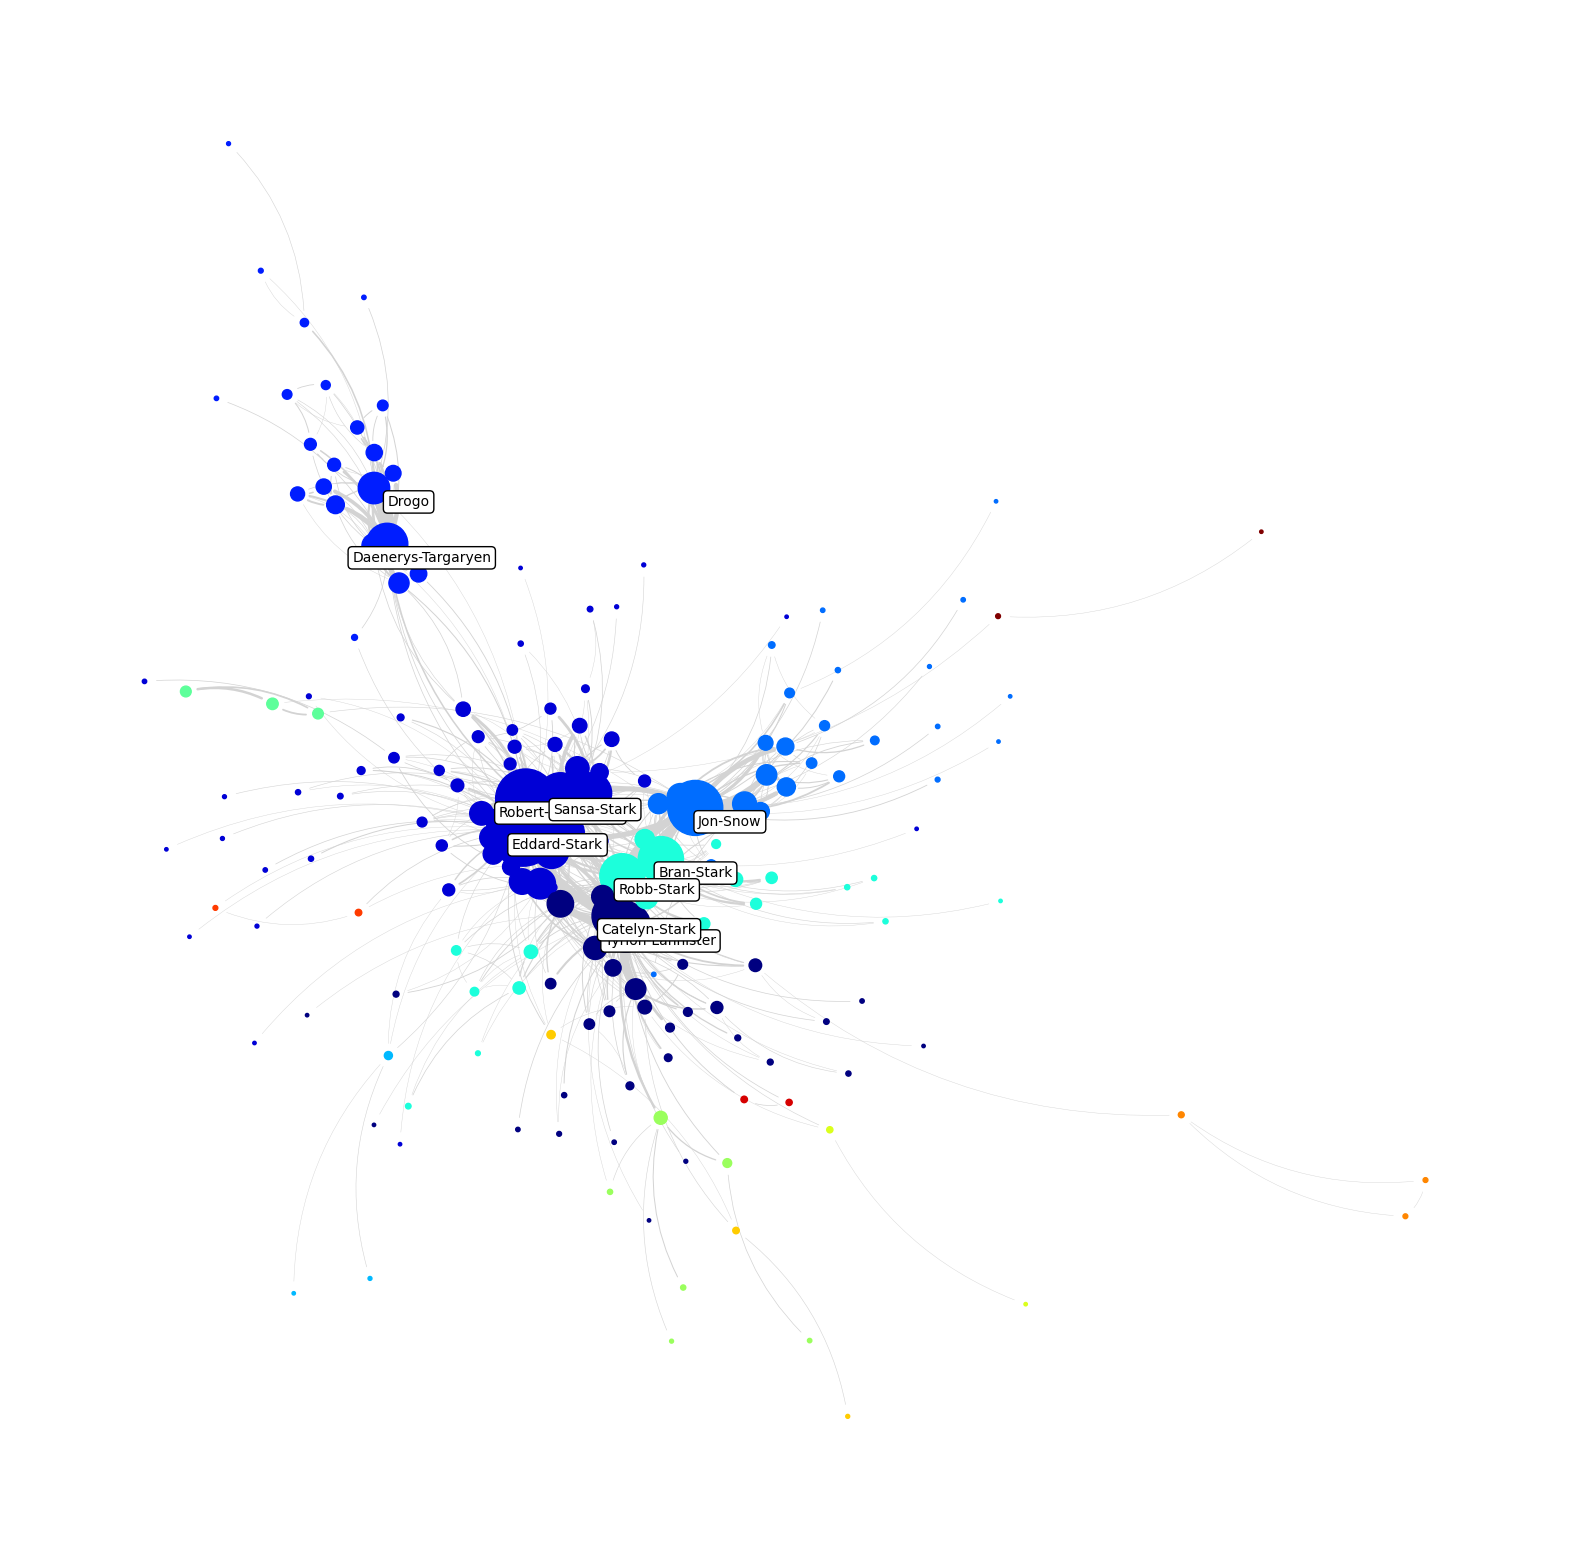

In [26]:
fig,ax=plt.subplots(1,1,figsize=(20,20))

nx.draw_networkx_nodes(G,pos=positions,node_size=sizes,node_color=colors_node_infomap)
nx.draw_networkx_labels(G,pos=pos_attrs,labels=labels,bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=.3'),font_size=10)
nx.draw_networkx_edges(G,pos=positions,connectionstyle="arc3,rad=0.2",arrows=True,edge_color='lightgrey',width=thickness)

plt.box(False)

In [27]:
print('The number of communities detected with Louvain is:',len(communities_louvain))
print('The number of communities detected with Greedy is:',len(communities_greedy))
print('The number of communities detected with Infomap is:',len(communities_infomap))
print(' ')
print('The modularity of the Louvain partition is:',nx.community.quality.modularity(G,communities_louvain))
print('The modularity of the Greedy partition is:',nx.community.quality.modularity(G,communities_greedy))
print('The modularity of the Infomap partition is:',nx.community.quality.modularity(G,communities_infomap))

The number of communities detected with Louvain is: 8
The number of communities detected with Greedy is: 7
The number of communities detected with Infomap is: 14
 
The modularity of the Louvain partition is: 0.5138368371267064
The modularity of the Greedy partition is: 0.43517968129872053
The modularity of the Infomap partition is: 0.4915406783845672


#### Are weights relevant?

In [28]:
communities_louvain_weighted=nx.community.louvain_communities(G,weight='weight') ## Louvain algorithm
communities_greedy_weighted=nx.community.greedy_modularity_communities(G,weight='weight') ## Greedy algorithm

colors_node_louvain=set_color_nodes(communities_louvain,G)
colors_node_greedy=set_color_nodes(communities_greedy,G)

print('The number of communities detected with Louvain (including weights) is:',len(communities_louvain_weighted))
print('The number of communities detected with Greedy (including weights) is:',len(communities_greedy_weighted))

print('The modularity of the Louvain partition (including weights) is:',nx.community.quality.modularity(G,communities_louvain_weighted))
print('The modularity of the Greedy partition (including weights) is:',nx.community.quality.modularity(G,communities_greedy_weighted))

The number of communities detected with Louvain (including weights) is: 8
The number of communities detected with Greedy (including weights) is: 7
The modularity of the Louvain partition (including weights) is: 0.5117635190680607
The modularity of the Greedy partition (including weights) is: 0.5101082687302116


In [29]:
communities_louvain

[{'Aegon-I-Targaryen',
  'Aggo',
  'Cohollo',
  'Daenerys-Targaryen',
  'Doreah',
  'Drogo',
  'Eroeh',
  'Fogo',
  'Haggo',
  'Illyrio-Mopatis',
  'Irri',
  'Jhiqui',
  'Jhogo',
  'Jommo',
  'Jorah-Mormont',
  'Mirri-Maz-Duur',
  'Ogo',
  'Qotho',
  'Quaro',
  'Rakharo',
  'Rhaego',
  'Viserys-Targaryen'},
 {'Aerys-II-Targaryen',
  'Alyn',
  'Arthur-Dayne',
  'Arys-Oakheart',
  'Balon-Greyjoy',
  'Barristan-Selmy',
  'Brandon-Stark',
  'Cayn',
  'Cersei-Lannister',
  'Daryn-Hornwood',
  'Eddard-Stark',
  'Gendry',
  'Gerold-Hightower',
  'Harwin',
  'Heward',
  'Howland-Reed',
  'Hugh',
  'Jacks',
  'Janos-Slynt',
  'Jon-Arryn',
  'Jory-Cassel',
  'Joss',
  'Lancel-Lannister',
  'Lyanna-Stark',
  'Oswell-Whent',
  'Petyr-Baelish',
  'Porther',
  'Pycelle',
  'Raymun-Darry',
  'Renly-Baratheon',
  'Rhaegar-Targaryen',
  'Robert-Baratheon',
  'Stannis-Baratheon',
  'Tobho-Mott',
  'Tomard',
  'Torrhen-Karstark',
  'Tregar',
  'Varly',
  'Varys',
  'Vayon-Poole',
  'Wyl-(guard)',
  'Wyll

#### Let us define a function to select a book, construct the network and extract the communities according to one chosen method

In [30]:
def communities_network_book(df,book,method):
    book_df=df[df['Book']==book]
    G=nx.from_pandas_edgelist(book_df,'Source','Target',edge_attr='weight')
    if(method=='louvain'):
        communities=nx.community.louvain_communities(G) ## Louvain algorithm
    if(method=='greedy'):
        communities=nx.community.greedy_modularity_communities(G)
    if(method=='infomap'):
        im = Infomap(silent=True) 
        mapping = im.add_networkx_graph(G)
        im.run()
        node_community_infomap = im.get_modules()
        communities=infomap_to_networkx_communities(mapping, node_community_infomap)

    return G,communities

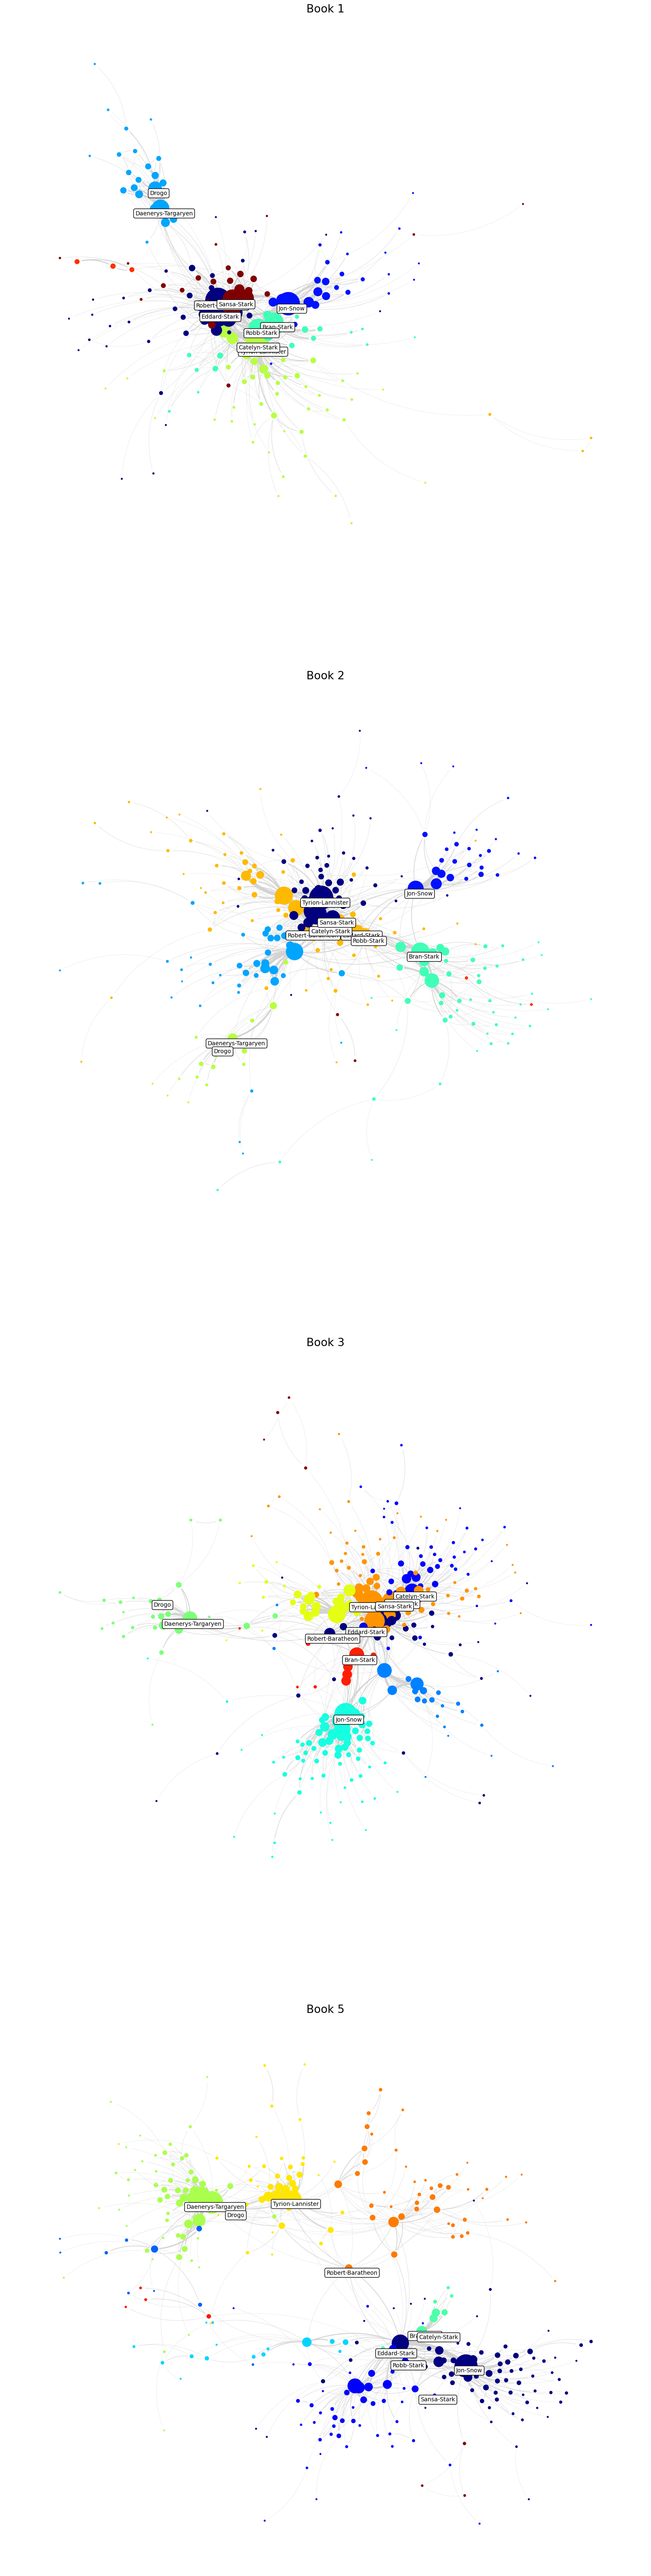

In [31]:
fig,ax=plt.subplots(4,1,figsize=(20,80))
count=0
for book in [1,2,3,5]:
    G,communities=communities_network_book(data,book,'louvain')
    positions=nx.spring_layout(G,k=.2,weight='weight',seed=1)
    sizes=[2*G.degree(node,weight='weight') for node in G.nodes()]
    thickness=[.1*G.edges()[edge]['weight'] for edge in G.edges()]

    ## Coordinates of the nodes' labels
    pos_attrs = {}
    for node, coords in positions.items():
        if node in highest_betweenness_nodes:
            pos_attrs[node] = (coords[0]+0.01, coords[1] - 0.02)

    colors_node=set_color_nodes(communities,G)
    nx.draw_networkx_nodes(G,pos=positions,node_size=sizes,node_color=colors_node,ax=ax[count])
    nx.draw_networkx_edges(G,pos=positions,connectionstyle="arc3,rad=0.2",arrows=True,edge_color='lightgrey',width=thickness,ax=ax[count])
    nx.draw_networkx_labels(G,pos=pos_attrs,labels=labels,bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=.3'),font_size=10,ax=ax[count])

    
    ax[count].axis('off')
    ax[count].set_title('Book '+str(int(book)))
    count=count+1